In [644]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from os.path import join, exists
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from PIL import Image
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data.sampler import SubsetRandomSampler, WeightedRandomSampler
from torch.utils.data import DataLoader, Subset, Dataset
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder, DatasetFolder
!pip install torchinfo
import torchinfo

# set seed
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

In [645]:
from google.colab import drive
drive.mount('/content/drive')

# get data and unzip (if not already)
if not exists('data_cleaned'):
  !unzip "/content/drive/My Drive/aps360/project_data_final"
else:
  print('Data already loaded')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data already loaded


In [683]:
BASE_DATA_PATH = 'data_cleaned'
IMAGE_PATH = join(BASE_DATA_PATH, 'images')
ANNOT_PATH = join(BASE_DATA_PATH, 'annotations')

In [684]:
df = pd.read_csv(join(ANNOT_PATH, 'master_alternate_augmented.csv'), dtype={'filename': str})
df = df[df['has bbox'] == True]
# remove is filename is nan
df = df[df['filename'].notna()]
df.reset_index(drop=True, inplace=True)

# Convert bounding box columns to numeric, coercing errors
for col in ['min_x', 'min_y', 'width', 'height']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where bounding box values became NaN after coercion
df.dropna(subset=['min_x', 'min_y', 'width', 'height'], inplace=True)
df.reset_index(drop=True, inplace=True)

n = len(df)
value_counts = df['label'].value_counts()
print(f"Total Samples: {n}")
print(value_counts)

Total Samples: 7374
label
bronchitis           2174
broncho-pnuemonia    2174
bronchiolitis        2174
other                 750
effusion               42
infiltration           23
heart disease          22
consolidation          15
Name: count, dtype: int64


In [648]:
## NOTE: UPDATE IMAGE SIZES TO BE 130x100 OR ELSE
## DOES NOT FIT INTO LOCAL OR COLAB RAM

from skimage import io
from skimage.transform import resize
from copy import deepcopy

df_new = deepcopy(df)
# DESIRED_IMG_SIZE = (520,400)
DESIRED_IMG_SIZE = (130, 100)

save_folder = 'data_small'
if not exists(save_folder):
  os.makedirs(save_folder)

for i in tqdm(range(len(df))):
  row = df.iloc[i]
  fname = row['filename']
  # load image
  img_path = os.path.join(IMAGE_PATH, fname)
  img = Image.open(img_path).convert('L')
  img = np.array(img)
  scaled_x = DESIRED_IMG_SIZE[0] / img.shape[0]
  scaled_y = DESIRED_IMG_SIZE[1] / img.shape[1]
  if not exists(join(save_folder, fname)):
    # resize
    img_resized = resize(img, DESIRED_IMG_SIZE, anti_aliasing=True)
    img_resized = (img_resized * 255).astype(np.uint8)
    # save
    save_path = join(save_folder, fname)
    Image.fromarray(img_resized).save(save_path)

100%|██████████| 7374/7374 [00:14<00:00, 524.09it/s]


augmented_bronchiolitis_1009.jpg
6678


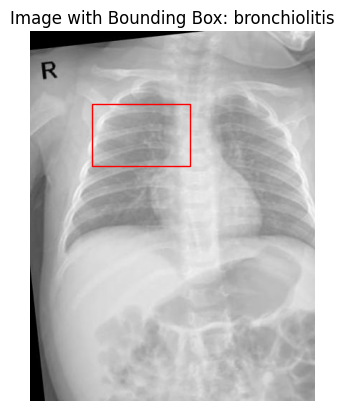

In [735]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Get a sample row from df_new that has a bounding box
idx = np.random.randint(0, len(df_new))
sample_row = df_new.iloc[idx]

fname = sample_row['filename']
print(fname)
print(idx)
min_x = sample_row['min_x']
min_y = sample_row['min_y']
width = sample_row['width']
height = sample_row['height']
label = sample_row['label']

# Load the resized image
img_path = os.path.join(IMAGE_PATH, fname)
img = Image.open(img_path).convert('L') # ensure grayscale

# Create figure and axes
fig, ax = plt.subplots(1)

# Display the image
ax.imshow(img, cmap='gray')

# Create a Rectangle patch
rect = patches.Rectangle((min_y, min_x), height, width, linewidth=1, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax.add_patch(rect)

plt.title(f"Image with Bounding Box: {label}")
plt.axis('off') # Hide axes
plt.show()

In [650]:
# BASE_DATA_PATH = '/home/orrin/aps360/pediatric-cxr-model/data_cleaned'
# IMAGE_PATH = join(BASE_DATA_PATH, 'images')
IMAGE_PATH = join(save_folder)
df_new.to_csv('master_alternate_augmented_small.csv', index=False)
# ANNOT_PATH = join(BASE_DATA_PATH, 'annotations')
ANNOT_PATH = os.path.curdir

In [658]:
# define custom dataset
class CXRLocalizationDataset(Dataset):
    def __init__(self, csv_file, image_dir, transform=None):
        self.image_dir = image_dir;
        self.transform = transform;
        # Explicitly define dtypes for bounding box columns to ensure they are read as floats
        self.data = pd.read_csv(csv_file, dtype={'min_x': float, 'min_y': float, 'width': float, 'height': float});
        # Encode labels as integers
        self.label_encoder = LabelEncoder();
        self.data['label_encoded'] = self.label_encoder.fit_transform(self.data['label']);
        self.label_decoder = {i: label for i, label in enumerate(self.label_encoder.classes_)};

    def __len__(self):
        return len(self.data);

    def __getitem__(self, idx):
        img_name = join(self.image_dir, self.data.iloc[idx]['filename']);
        image = Image.open(img_name).convert('L');  # convert to grayscale
        # label = self.data.iloc[idx]['label_encoded']  # Could inlcude labels later if wanted
        bbox = self.data.iloc[idx][['min_x', 'min_y', 'width', 'height']].values;
        # Explicitly cast to float32 numpy array before converting to torch.tensor
        bbox = bbox.astype(np.float32)
        bbox = torch.tensor(bbox, dtype=torch.float32);
        if self.transform:
            image = self.transform(image);
        return image, bbox;

In [659]:
def ConvBlock(in_channels, out_channels, kernel_size=3, stride=1, padding=1, dropout=0.2):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
        nn.SiLU(inplace=True),
        nn.BatchNorm2d(out_channels),
        nn.Dropout2d(dropout)
    )

def FeedForwardBlock(in_features, out_features, dropout=0.2):
    return nn.Sequential(
        nn.Linear(in_features, out_features),
        nn.SiLU(inplace=True),
        nn.BatchNorm1d(out_features),
        nn.Dropout(dropout)
    )

def FeedForwardLastLayer(in_features, out_features):
    return nn.Sequential(
        nn.Linear(in_features, out_features),
    )

class ComposableCNN(nn.Module):
    def __init__(self, conv_params):
        super(ComposableCNN, self).__init__()
        self.params = conv_params
        self.n_conv_layers = len(conv_params)

        for i, (in_ch, out_ch, k, s, p, d) in enumerate(conv_params):
            setattr(self, f'block{i+1}', ConvBlock(in_ch, out_ch, k, s, p, d))

    def forward(self, x):
        for i in range(1, self.n_conv_layers + 1):
            block = getattr(self, f'block{i}')
            x = block(x)
        return x

class ComposableFFN(nn.Module):
    def __init__(self, fc_params):
        super(ComposableFFN, self).__init__()
        self.params = fc_params
        self.n_ff_layers = len(fc_params)

        for i, (in_ch, out_ch, d) in enumerate(fc_params):
            if i == self.n_ff_layers - 1:
                setattr(self, f'block{i+1}', FeedForwardLastLayer(in_ch, out_ch))
            else:
                setattr(self, f'block{i+1}', FeedForwardBlock(in_ch, out_ch, d))

    def forward(self, x):
        for i in range(1, self.n_ff_layers + 1):
            block = getattr(self, f'block{i}')
            x = block(x)
        return x

class PediatricCXRClassificationModel(nn.Module):
    def __init__(self, name, conv_params, fc_params):
        super(PediatricCXRClassificationModel, self).__init__()
        self.name = name
        self.cnn = ComposableCNN(conv_params)
        self.ffn = ComposableFFN(fc_params)

    def forward(self, x):
        x = self.cnn(x)
        x = torch.flatten(x, 1)  # Flatten all dimensions except batch
        x = self.ffn(x)
        return x

In [669]:
"""
Create Classifier Architecture. Get CNN Weights.
Create Localization Architecture. Apply CNN Weights.
"""

### CNN ARCHITECTURE
conv_params = [
    (1, 4, 7, 2, 1, 0.4),   # Input: (1, 130, 100) -> Output: (4, 63, 48)
    (4, 8, 3, 2, 1, 0.4),  # Input: (4, 63, 48) -> Output: (8, 32, 24)
    (8, 16, 5, 2, 1, 0.4),  # Input: (8, 32, 24) -> Output: (16, 15, 11)
    (16, 32, 3, 2, 1, 0.4), # Input: (16, 15, 11) -> Output: (32, 8, 6)
    (32, 64, 3, 2, 1, 0.4)  # Input: (32, 8, 6) -> Output: (64, 4, 3)
]

### CLASSIFICATION ARCHITECTURE
# Calculate the input size for the feedforward network based on CNN output
# Last CNN layer output channels: 64
# Last CNN layer output height: 4
# Last CNN layer output width: 3
ffn_input_size = 64 * 4 * 3 # This is 768

# Define feedforward parameters for a two-layer FFN
# (in_features, out_features, dropout)
fc_params = [
    (ffn_input_size, 16, 0.4), # First hidden layer
    (16, 10, 0.0) # Output layer for 10 classes (dropout not applied to output)
]

### GET WEIGHTS
# Create the PediatricCXRClassificationModel
model = PediatricCXRClassificationModel('final', conv_params, fc_params)
# load cnn weights from classifier
path = 'model_final_bs128_lr0.0001_epoch184'
model.load_state_dict(torch.load(path))
torch.save(model.cnn.state_dict(), 'cnn_weights')

### LOCALIZATION ARCHITECTURE
fc_params = [
    (ffn_input_size, 16, 0.4), # First hidden layer
    (16, 4, 0.0) # Output layer for 4 bbox coordinates
]

### APPLY CNN WEIGHTS AND FREEZE
# Create the PediatricCXRClassificationModel
model = PediatricCXRClassificationModel('final', conv_params, fc_params)
model.cnn.load_state_dict(torch.load('cnn_weights'))
for param in model.cnn.parameters():
    param.requires_grad = False
for param in model.ffn.parameters():
    param.requires_grad = True

torchinfo.summary(model, input_size=(1, 1, 130, 100))


Layer (type:depth-idx)                   Output Shape              Param #
PediatricCXRClassificationModel          [1, 4]                    --
├─ComposableCNN: 1-1                     [1, 64, 4, 3]             --
│    └─Sequential: 2-1                   [1, 4, 63, 48]            --
│    │    └─Conv2d: 3-1                  [1, 4, 63, 48]            (200)
│    │    └─SiLU: 3-2                    [1, 4, 63, 48]            --
│    │    └─BatchNorm2d: 3-3             [1, 4, 63, 48]            (8)
│    │    └─Dropout2d: 3-4               [1, 4, 63, 48]            --
│    └─Sequential: 2-2                   [1, 8, 32, 24]            --
│    │    └─Conv2d: 3-5                  [1, 8, 32, 24]            (296)
│    │    └─SiLU: 3-6                    [1, 8, 32, 24]            --
│    │    └─BatchNorm2d: 3-7             [1, 8, 32, 24]            (16)
│    │    └─Dropout2d: 3-8               [1, 8, 32, 24]            --
│    └─Sequential: 2-3                   [1, 16, 15, 11]           --
│    │

In [661]:
csv_file = join(ANNOT_PATH, 'master_alternate_augmented_small.csv')
# csv_file = join(ANNOT_PATH, 'master_alternate_augmented.csv')
dataset = CXRLocalizationDataset(
    csv_file=csv_file,
    image_dir=IMAGE_PATH,
    transform=transforms.ToTensor()
)

In [665]:
# helper funtion to split train, validation, and test sets and get loaders
# includes utility to get a certain percentage of the data (useful for question 2c)
def get_data_loaders(
    data,
    percent_train,
    percent_validation,
    percent_test,
    batch_size,
    percent_data=1.0):
  # Ensure splits add up to one
  assert percent_train + percent_validation + percent_test == 1.0, \
    "Split percentages must add up to 1.0"

  # randomly define data to use based on percent
  indices = np.random.choice(len(data), int(len(data) * percent_data))
  data_to_use = Subset(data, indices)

  # load splits
  data_train, data_validate_test = train_test_split(data_to_use, train_size=percent_train,
                                                    shuffle=True)
  data_validate, data_test = train_test_split(data_validate_test, \
      train_size=percent_validation/(percent_validation+percent_test),
                                              shuffle=True)
  print("Train Size:", len(data_train))
  print("Validation Size:", len(data_validate))
  print("Test Size:", len(data_test))

  # create dataloaders
  loader_train = DataLoader(data_train, batch_size=batch_size, shuffle=True, drop_last=True)
  loader_validate = DataLoader(data_validate, batch_size=batch_size, shuffle=True)
  loader_test = DataLoader(data_test, batch_size=batch_size, shuffle=True)

  return loader_train, loader_validate, loader_test

In [666]:
# Functions based off of Lab 2: Cat and Dogs
def get_model_name(name, batch_size, learning_rate, epoch):
    """ Generate a name for the model consisting of all the hyperparameter values

    Args:
        config: Configuration object containing the hyperparameters
    Returns:
        path: A string with the hyperparameter name and value concatenated
    """
    path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name,
                                                   batch_size,
                                                   learning_rate,
                                                   epoch)
    return path

def iou_loss(predictions, targets):
    """
    Calculates the IoU loss for bounding box regression.
    predictions and targets are expected in [min_x, min_y, width, height] format.
    """
    # Convert predictions and targets from [min_x, min_y, width, height] to [x1, y1, x2, y2]
    pred_x1 = predictions[:, 0]
    pred_y1 = predictions[:, 1]
    pred_x2 = predictions[:, 0] + predictions[:, 2]
    pred_y2 = predictions[:, 1] + predictions[:, 3]

    target_x1 = targets[:, 0]
    target_y1 = targets[:, 1]
    target_x2 = targets[:, 0] + targets[:, 2]
    target_y2 = targets[:, 1] + targets[:, 3]

    # Calculate intersection coordinates
    inter_x1 = torch.max(pred_x1, target_x1)
    inter_y1 = torch.max(pred_y1, target_y1)
    inter_x2 = torch.min(pred_x2, target_x2)
    inter_y2 = torch.min(pred_y2, target_y2)

    # Calculate intersection area
    inter_width = torch.clamp(inter_x2 - inter_x1, min=0)
    inter_height = torch.clamp(inter_y2 - inter_y1, min=0)
    intersection_area = inter_width * inter_height

    # Calculate union area
    pred_area = predictions[:, 2] * predictions[:, 3]
    target_area = targets[:, 2] * targets[:, 3]
    union_area = pred_area + target_area - intersection_area

    # Calculate IoU
    iou = intersection_area / (union_area + 1e-6)  # Add epsilon to prevent division by zero

    # IoU loss: 1 - IoU
    loss = 1.0 - iou
    return loss.mean(), iou.mean()


def evaluate(net, loader):
    """ Evaluate the network on the validation set.

     Args:
         net: PyTorch neural network object
         loader: PyTorch data loader for the validation set
     Returns:
         avg_loss: A scalar for the average loss function over the validation set
         avg_iou: A scalar for the average IoU over the validation set
     """
     # set up variables
    total_loss = 0.0
    total_iou = 0.0
    total_samples = 0

    if torch.cuda.is_available():
      net = net.cuda()
    net.eval() # turn off dropout

    # compute correct predictions and loss for each batch
    # save samples for future accuracy prediction
    for i, data in enumerate(loader, 0):
        inputs, targets = data # targets are now bounding boxes
        if torch.cuda.is_available():
            inputs = inputs.cuda()
            targets = targets.cuda()

        outputs = net(inputs)
        loss, iou = iou_loss(outputs, targets)

        total_loss += loss.item() * inputs.size(0) # Multiply by batch size for correct averaging
        total_iou += iou.item() * inputs.size(0)
        total_samples += inputs.size(0)

    # compute total average loss and IoU
    avg_loss = total_loss / total_samples
    avg_iou = total_iou / total_samples
    return avg_iou, avg_loss


def train_net(net,
              train_loader,
              val_loader,
              batch_size=32,
              learning_rate=0.01,
              num_epochs=30,
              checkpoint_freq=20):

    if torch.cuda.is_available():
      net = net.cuda()
    net.train() # put model into training mode
    ########################################################################
    # Define the Loss function and optimizer
    # The loss function will be IoU Loss.
    # Optimizer will be SGD with Momentum.

    criterion = iou_loss # Use the custom IoU loss function
    optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9)

    ########################################################################
    # Set up some numpy arrays to store the training/validation loss/iou
    train_iou = np.zeros(num_epochs)
    train_loss = np.zeros(num_epochs)
    val_iou = np.zeros(num_epochs)
    val_loss = np.zeros(num_epochs)

    ########################################################################
    # Train the network
    # Loop over the data iterator and sample a new batch of training data
    # Get the output from the network, and optimize our loss function.
    start_time = time.time()
    for epoch in range(num_epochs):
        total_train_loss = 0.0
        total_train_iou = 0.0
        total_samples = 0

        for i, data in enumerate(train_loader, 0):
            # Get the inputs
            inputs, targets = data # targets are now bounding boxes
            if torch.cuda.is_available():
                inputs = inputs.cuda()
                targets = targets.cuda()

            # Zero the parameter gradients
            optimizer.zero_grad()
            # Forward pass, backward pass, and optimize
            outputs = net(inputs)
            loss, iou = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            # Calculate the statistics
            total_train_loss += loss.item() * inputs.size(0)
            total_train_iou += iou.item() * inputs.size(0)
            total_samples += inputs.size(0)

        train_iou[epoch] = total_train_iou / total_samples
        train_loss[epoch] = total_train_loss / total_samples
        val_iou[epoch], val_loss[epoch] = evaluate(net, val_loader)
        print(("Epoch {}: Train IoU: {:.4f}, Train loss: {:.4f} |"+
               "Validation IoU: {:.4f}, Validation loss: {:.4f}").format(
                   epoch + 1,
                   train_iou[epoch],
                   train_loss[epoch],
                   val_iou[epoch],
                   val_loss[epoch]))

        # Save the current model (checkpoint) to a file
        model_path = get_model_name(net.name, batch_size, learning_rate, epoch)
        if epoch % checkpoint_freq == 0:
            torch.save(net.state_dict(), model_path)

    print('Finished Training')
    end_time = time.time()
    elapsed_time = end_time - start_time
    print("Total time elapsed: {:.2f} seconds".format(elapsed_time))
    # Write the train/test loss/err into CSV file for plotting later
    np.savetxt("{}_train_iou.csv".format(model_path), train_iou)
    np.savetxt("{}_train_loss.csv".format(model_path), train_loss)
    np.savetxt("{}_val_iou.csv".format(model_path), val_iou)
    np.savetxt("{}_val_loss.csv".format(model_path), val_loss)


def plot_training_curve(path):
    """ Plots the training curve for a model run, given the csv files
    containing the train/validation error/loss.

    Args:
        path: The base path of the csv files produced during training
    """
    import matplotlib.pyplot as plt
    train_iou = np.loadtxt("{}_train_iou.csv".format(path))
    val_iou = np.loadtxt("{}_val_iou.csv".format(path))
    train_loss = np.loadtxt("{}_train_loss.csv".format(path))
    val_loss = np.loadtxt("{}_val_loss.csv".format(path))

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Train vs Validation IoU")
    n = len(train_iou) # number of epochs
    plt.plot(range(1,n+1), train_iou, label="Train")
    plt.plot(range(1,n+1), val_iou, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.legend(loc='best')

    plt.subplot(1, 2, 2)
    plt.title("Train vs Validation Loss")
    plt.plot(range(1,n+1), train_loss, label="Train")
    plt.plot(range(1,n+1), val_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')
    plt.show()

def pipeline(
    model,
    dataset,
    batch_size=32,
    learning_rate=0.001,
    num_epochs=10,
    percent_train=0.7,
    percent_validation=0.15,
    percent_test=0.15,
    percent_data=0.05,
    checkpoint_freq=1
):
    # get data loaders
    loader_train, loader_validate, loader_test = get_data_loaders(
        dataset,
        percent_train=percent_train,
        percent_validation=percent_validation,
        percent_test=percent_test,
        batch_size=batch_size,
        percent_data=percent_data
    )

    # train model
    train_net(model,
              loader_train,
              loader_validate,
              batch_size=batch_size,
              learning_rate=learning_rate,
              num_epochs=num_epochs,
              checkpoint_freq=checkpoint_freq)

In [670]:
# overfit on subset
pipeline(
    model,
    dataset,
    batch_size=32,
    learning_rate=0.001,
    num_epochs=200,
    percent_train=0.7,
    percent_validation=0.15,
    percent_test=0.15,
    percent_data=0.05,
    checkpoint_freq=1,
)

Train Size: 257
Validation Size: 55
Test Size: 56
Epoch 1: Train IoU: 0.0000, Train loss: 1.0000 |Validation IoU: 0.0000, Validation loss: 1.0000
Epoch 2: Train IoU: 0.0000, Train loss: 1.0000 |Validation IoU: 0.0000, Validation loss: 1.0000
Epoch 3: Train IoU: 0.0000, Train loss: 1.0000 |Validation IoU: 0.0000, Validation loss: 1.0000
Epoch 4: Train IoU: 0.0000, Train loss: 1.0000 |Validation IoU: 0.0000, Validation loss: 1.0000
Epoch 5: Train IoU: 0.0000, Train loss: 1.0000 |Validation IoU: 0.0000, Validation loss: 1.0000
Epoch 6: Train IoU: 0.0000, Train loss: 1.0000 |Validation IoU: 0.0000, Validation loss: 1.0000
Epoch 7: Train IoU: 0.0000, Train loss: 1.0000 |Validation IoU: 0.0000, Validation loss: 1.0000
Epoch 8: Train IoU: 0.0000, Train loss: 1.0000 |Validation IoU: 0.0000, Validation loss: 1.0000
Epoch 9: Train IoU: 0.0000, Train loss: 1.0000 |Validation IoU: 0.0000, Validation loss: 1.0000
Epoch 10: Train IoU: 0.0000, Train loss: 1.0000 |Validation IoU: 0.0000, Validation lo

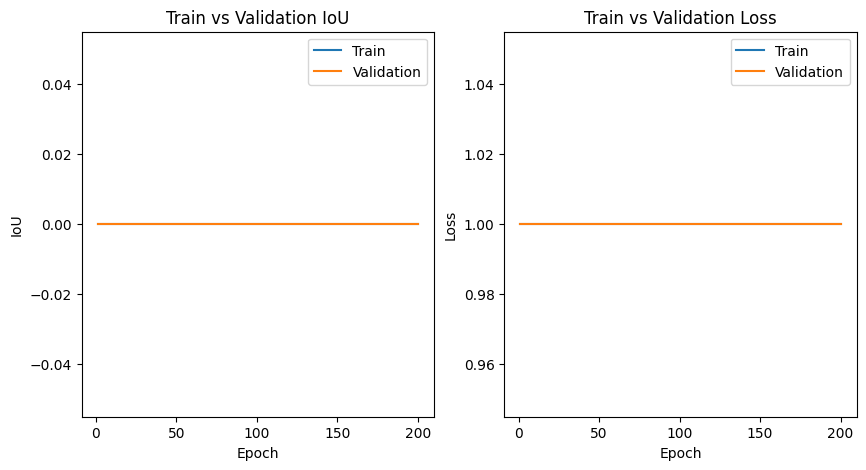

In [671]:
path = get_model_name(model.name, 32, 0.001, 199)
plot_training_curve(path)

In [673]:
pipeline(
    model,
    dataset,
    batch_size=264,
    learning_rate=0.001,
    num_epochs=200,
    percent_train=0.7,
    percent_validation=0.15,
    percent_test=0.15,
    percent_data=1.0,
    checkpoint_freq=1,
)

Train Size: 5161
Validation Size: 1106
Test Size: 1107
Epoch 1: Train IoU: 0.0000, Train loss: 1.0000 |Validation IoU: 0.0000, Validation loss: 1.0000
Epoch 2: Train IoU: 0.0000, Train loss: 1.0000 |Validation IoU: 0.0000, Validation loss: 1.0000
Epoch 3: Train IoU: 0.0000, Train loss: 1.0000 |Validation IoU: 0.0000, Validation loss: 1.0000
Epoch 4: Train IoU: 0.0000, Train loss: 1.0000 |Validation IoU: 0.0000, Validation loss: 1.0000
Epoch 5: Train IoU: 0.0000, Train loss: 1.0000 |Validation IoU: 0.0000, Validation loss: 1.0000
Epoch 6: Train IoU: 0.0000, Train loss: 1.0000 |Validation IoU: 0.0000, Validation loss: 1.0000
Epoch 7: Train IoU: 0.0000, Train loss: 1.0000 |Validation IoU: 0.0000, Validation loss: 1.0000
Epoch 8: Train IoU: 0.0000, Train loss: 1.0000 |Validation IoU: 0.0000, Validation loss: 1.0000
Epoch 9: Train IoU: 0.0000, Train loss: 1.0000 |Validation IoU: 0.0000, Validation loss: 1.0000
Epoch 10: Train IoU: 0.0000, Train loss: 1.0000 |Validation IoU: 0.0000, Validati